In [1]:
import pandas as pd

In [3]:
df_row_data = pd.read_excel(r"W33836_business_analytics.xlsx", sheet_name=1)
# df_row_data.head(3)
df_row_data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [54]:
df_row_data.head(10).T

,0,1,2,3,4,5,6,7,8,9
ID,5524,2174,4141,6182,5324,7446,965,6177,4855,5899
Year_Birth,1957,1954,1965,1984,1981,1967,1971,1985,1974,1950
Education,Graduation,Graduation,Graduation,Graduation,PhD,Master,Graduation,PhD,PhD,PhD
Marital_Status,Single,Single,Together,Together,Married,Together,Divorced,Married,Together,Together
Income,58138.0,46344.0,71613.0,26646.0,58293.0,62513.0,55635.0,33454.0,30351.0,5648.0
Kidhome,0,1,0,1,1,0,0,1,1,1
Teenhome,0,1,0,0,0,1,1,0,0,1
Dt_Customer,2012-04-09 00:00:00,2014-08-03 00:00:00,2013-08-21 00:00:00,2014-10-02 00:00:00,2014-01-19 00:00:00,2013-09-09 00:00:00,2012-11-13 00:00:00,2013-08-05 00:00:00,2013-06-06 00:00:00,2014-03-13 00:00:00
Recency,58,38,26,26,94,16,34,32,19,68
MntWines,635,11,426,11,173,520,235,76,14,28


In [5]:
# Check row data
df_row_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# DataType

In [4]:
# DT_Customer
df_row_data['Dt_Customer'] = pd.to_datetime(df_row_data['Dt_Customer'], errors='coerce')

In [5]:
df_row_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [45]:
df_row_data["Dt_Customer"].head(10)

0   2012-04-09
1   2014-08-03
2   2013-08-21
3   2014-10-02
4   2014-01-19
5   2013-09-09
6   2012-11-13
7   2013-08-05
8   2013-06-06
9   2014-03-13
Name: Dt_Customer, dtype: datetime64[ns]

# Duplicated


In [6]:
df_row_data.duplicated(subset=["ID"]).sum()

np.int64(0)

# Missing
## Replace with mode (Need to change) 

In [47]:
# Missing values
df_row_data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [39]:
df_income_not_missing = df_row_data.query("not Income.isna()")
income_mode = int(df_income_not_missing["Income"].mode())

C:\Users\user\AppData\Local\Temp\ipykernel_17644\170227312.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  income_mode = int(df_income_not_missing["Income"].mode())


In [37]:
df_row_data.loc[df_row_data.query('Income.isnull()').index, 'Income'] = income_mode


In [40]:
df_row_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [42]:
df_row_data.isna().sum()
df_dropna = df_row_data.copy()

# Outliner

In [43]:
df_dropna.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Year_Birth,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Income,2240.0,51767.816518,1730.0,34722.0,51075.0,68289.75,666666.0,25458.285477
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-11 22:57:38.571428608,2012-01-08 00:00:00,2013-01-19 18:00:00,2013-07-11 00:00:00,2013-12-30 06:00:00,2014-12-06 00:00:00,NaN
Recency,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MntMeatProducts,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373


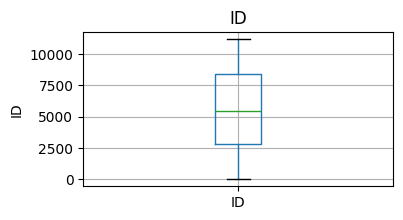

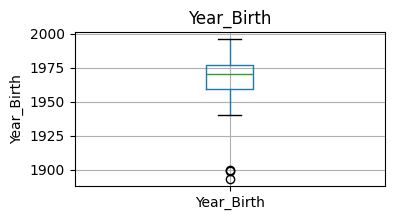

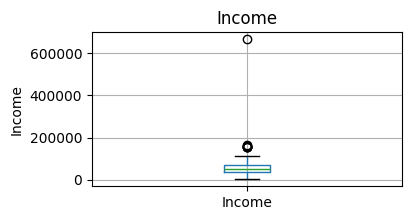

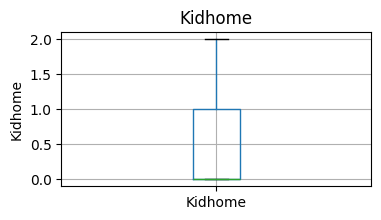

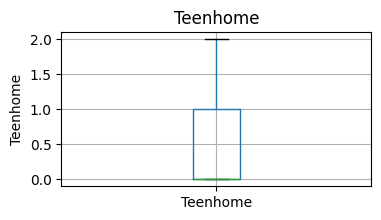

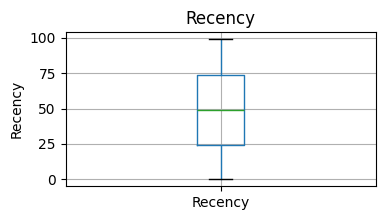

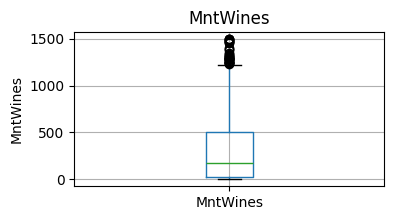

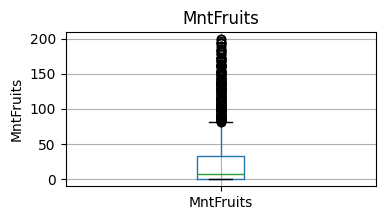

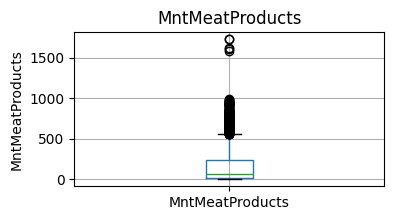

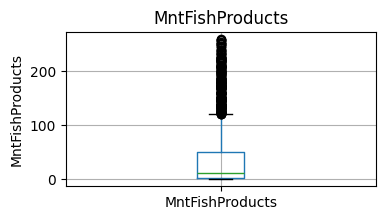

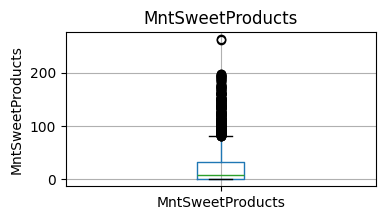

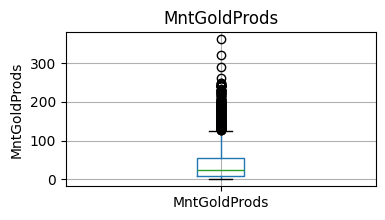

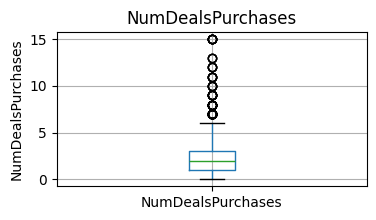

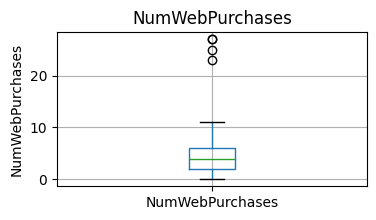

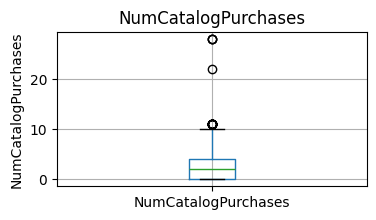

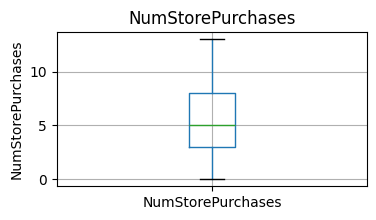

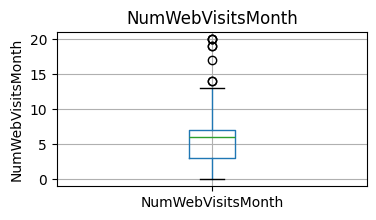

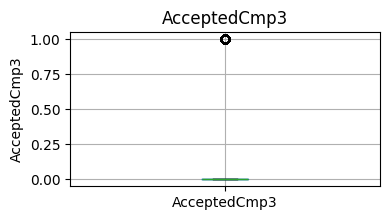

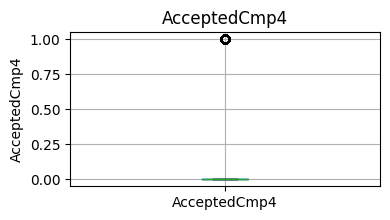

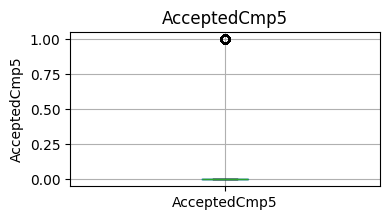

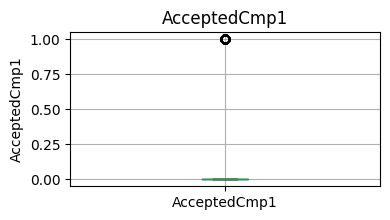

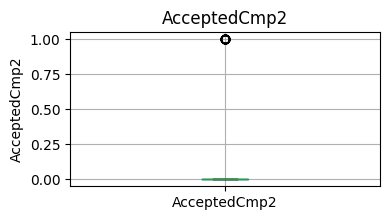

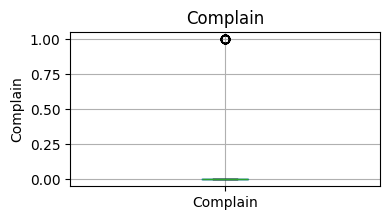

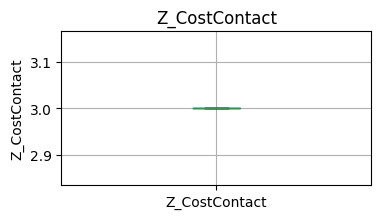

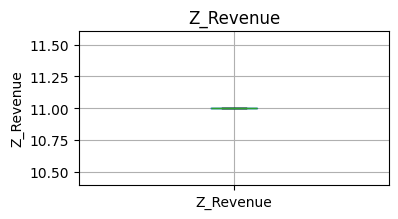

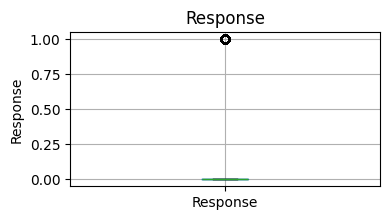

In [46]:
import matplotlib.pyplot as plt
number_columns = df_dropna.select_dtypes(include='number').columns

for column in number_columns:
    plt.figure(figsize=(4,2))
    df_dropna.boxplot(column=column)
    plt.title(f'{column}')
    plt.ylabel(column)
    plt.show()

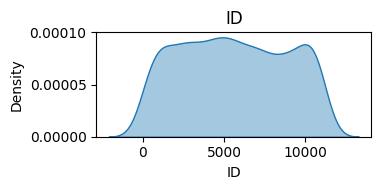

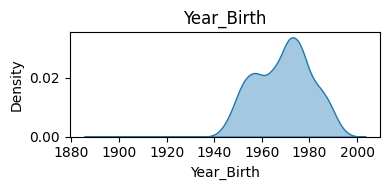

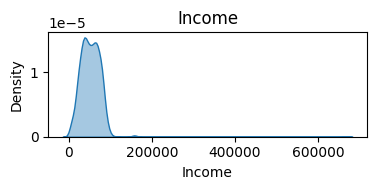

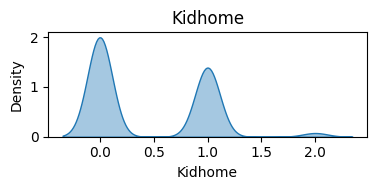

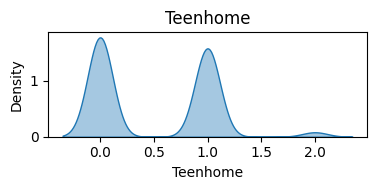

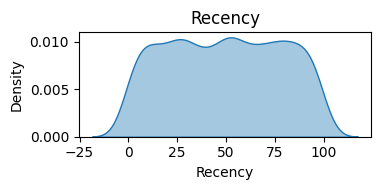

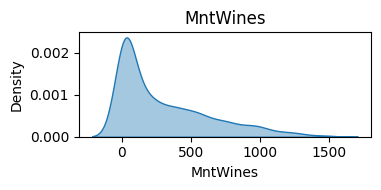

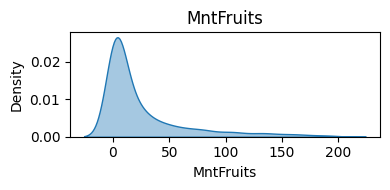

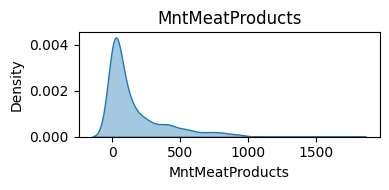

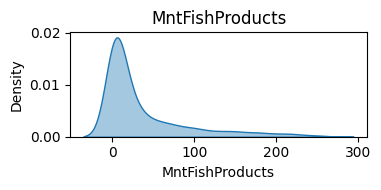

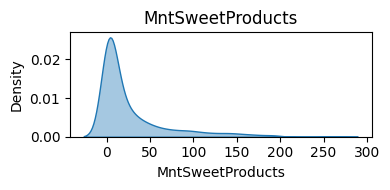

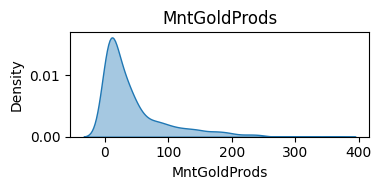

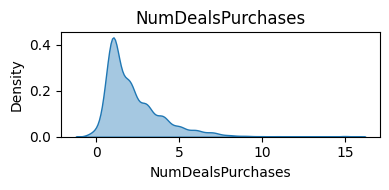

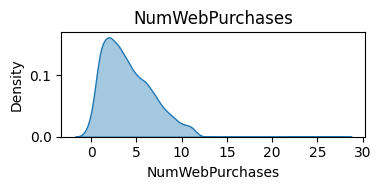

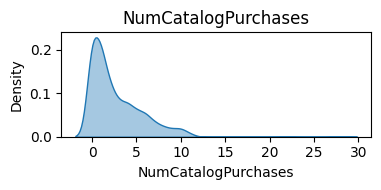

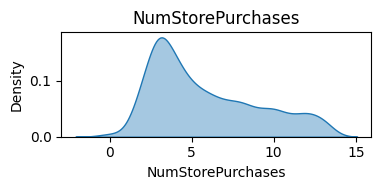

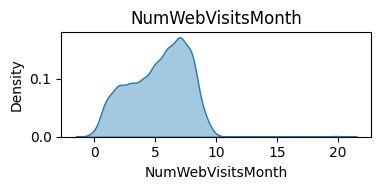

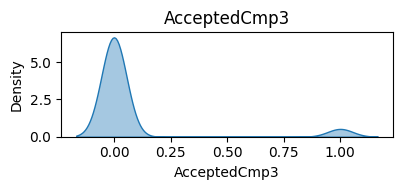

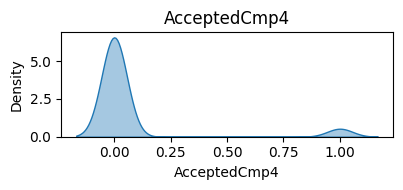

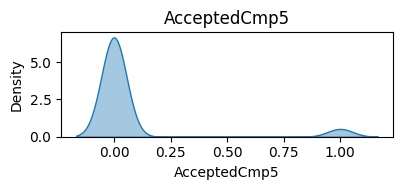

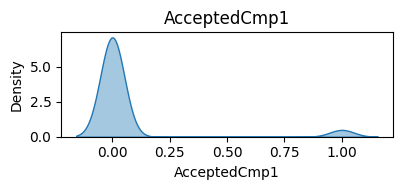

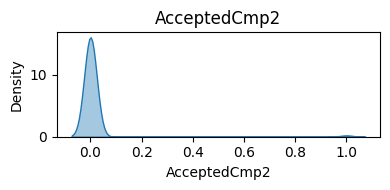

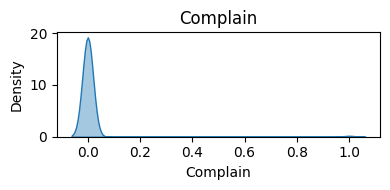

C:\Users\user\AppData\Local\Temp\ipykernel_17644\1497750416.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_dropna, x=column, fill=True, alpha=0.4)


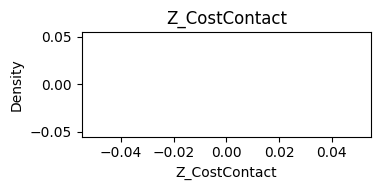

C:\Users\user\AppData\Local\Temp\ipykernel_17644\1497750416.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_dropna, x=column, fill=True, alpha=0.4)


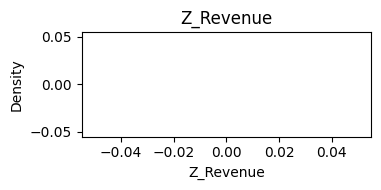

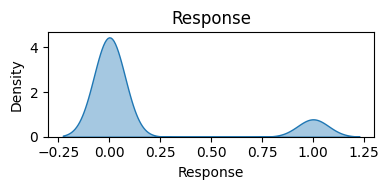

In [47]:
import seaborn as sns
for column in number_columns:
    # plt.figure(figsize=(4,2))
    # df_dropna.scatter(column=column)
    # plt.title(f'{column}')
    # plt.ylabel(column)
    # plt.show()
    plt.figure(figsize=(4, 2))
    sns.kdeplot(data=df_dropna, x=column, fill=True, alpha=0.4)
    plt.title(f'{column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

<Axes: title={'center': 'Before'}>

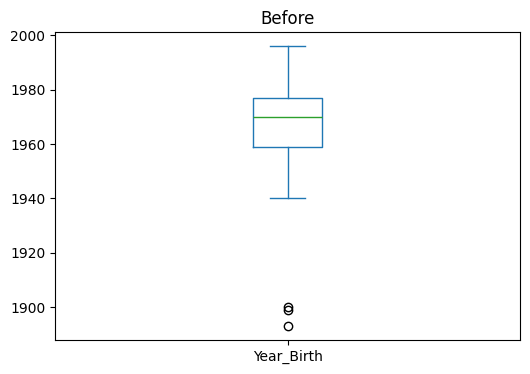

In [48]:
df_dropna["Year_Birth"].plot.box(figsize=(6, 4), title="Before")

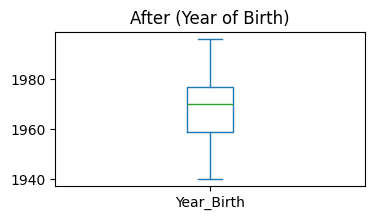

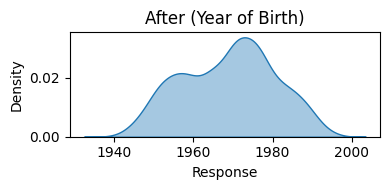

In [55]:
# Year of Birth
df_cleaned_1 = df_dropna.query("Year_Birth > 1925")
df_cleaned_1["Year_Birth"].plot.box(figsize=(4, 2), title="After (Year of Birth)")
# df_cleaned_1.describe().T

plt.figure(figsize=(4, 2))
sns.kdeplot(data=df_cleaned_1, x="Year_Birth", fill=True, alpha=0.4)
plt.title(f'After (Year of Birth)')
plt.xlabel(column)
plt.ylabel('Density')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Before Income'}>

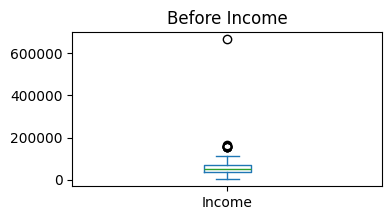

In [61]:
# Income
df_cleaned_1["Income"].plot.box(figsize=(4, 2), title="Before Income")

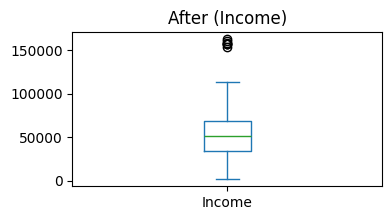

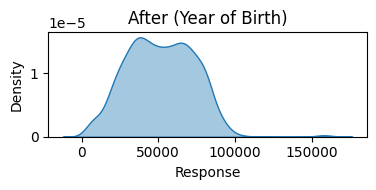

In [60]:
df_cleaned_2 = df_cleaned_1.query("Income < 600000")
df_cleaned_2["Income"].plot.box(figsize=(4, 2), title="After (Income)")
# df_cleaned.describe().T

plt.figure(figsize=(4, 2))
sns.kdeplot(data=df_cleaned_2, x="Income", fill=True, alpha=0.4)
plt.title(f'After (Year of Birth)')
plt.xlabel(column)
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# Final dataset

In [62]:
df_cleaned_2.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236,2236.000000,2236.00000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.0,2236.0,2236.000000
mean,5589.008497,1968.898032,51481.614043,0.444097,0.506708,2013-07-11 19:41:06.547406080,49.116279,304.12746,26.275939,166.983453,...,5.318873,0.072898,0.074687,0.072451,0.064401,0.013417,0.008945,3.0,11.0,0.149374
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,34686.250000,0.000000,0.000000,2013-01-19 00:00:00,24.000000,24.00000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5454.500000,1970.000000,51025.500000,0.000000,0.000000,2013-07-11 00:00:00,49.000000,174.00000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68275.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.25000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.00000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3244.826887,11.703281,21896.224254,0.538459,0.544609,NaN,28.957284,336.59181,39.724007,225.689645,...,2.426886,0.260027,0.262944,0.259291,0.245520,0.115077,0.094173,0.0,0.0,0.356536


In [63]:
df_cleaned_2.to_csv("Business_Analytics_Cleaned_Dataset.csv", index=False)
df_cleaned_2.to_excel("Business_Analytics_Cleaned_Dataset.xlsx", index=False)